# 04 Timebase, Resample, Synchronize

Real logs often share a physical clock but not a sample grid. This notebook separates single-object evaluation, pairwise interpolation, and multi-object synchronization.


## Imports

Imports are kept separate so the instructional cells can focus on TAL semantics.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
from IPython.display import display
from tal import AnalysisObject
from tal.core import ParamEvalOptions, ParamSyncOptions, synchronize

from pathlib import Path
import sys

_release_dir = Path.cwd()
if not (_release_dir / '_helpers.py').exists():
    candidate = Path.cwd() / 'examples' / 'release'
    if candidate.exists():
        _release_dir = candidate
if str(_release_dir) not in sys.path:
    sys.path.append(str(_release_dir))

from _helpers import (
    build_framegraph_spatial_payloads,
    build_topology_edge_payloads,
    compact_dataset,
    display_result,
    explain_expected_failure,
    make_imu_gps_alignment_aos,
    make_kinematics_demo_objects,
    make_pose_demo_objects,
    show_ao,
    summarize_ao,
)


## Setup: two streams with different clocks

The IMU-like stream is high-rate; the GPS-like stream is low-rate. Both use `time_s` as their param coordinate.


#### Input streams

,stream,samples,vars
0,IMU,201,[imu_speed_mps]
1,GPS,21,[gps_speed_mps]


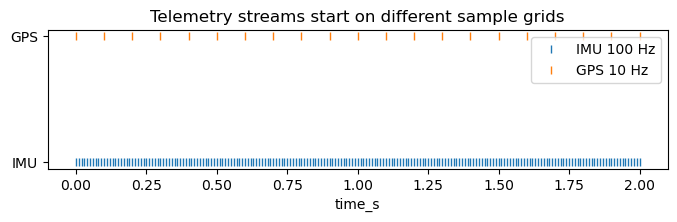

In [2]:
ao_imu, ao_gps = make_imu_gps_alignment_aos()

display_result(
    'Input streams',
    pd.DataFrame(
        [
            {'stream': 'IMU', 'samples': ao_imu.unsafe_data.sizes['sample'], 'vars': list(ao_imu.unsafe_data.data_vars)},
            {'stream': 'GPS', 'samples': ao_gps.unsafe_data.sizes['sample'], 'vars': list(ao_gps.unsafe_data.data_vars)},
        ]
    ),
)

fig, ax = plt.subplots(figsize=(8, 1.8))
ax.plot(ao_imu.unsafe_data['time_s'], np.zeros(ao_imu.unsafe_data.sizes['sample']), '|', label='IMU 100 Hz')
ax.plot(ao_gps.unsafe_data['time_s'], np.ones(ao_gps.unsafe_data.sizes['sample']), '|', label='GPS 10 Hz')
ax.set(
    title='Telemetry streams start on different sample grids',
    xlabel='time_s',
    yticks=[0, 1],
    yticklabels=['IMU', 'GPS'],
)
ax.legend(loc='upper right')


## Single-object param operations

Use `.param.at` for an explicit query grid, `.param.resample_to` for a target grid, and `.param.interp_like` when another AO supplies the grid.


#### Param operation outputs

,operation,samples,vars
0,imu.param.at(linear),41,[imu_speed_mps]
1,gps.param.resample_to(nearest),41,[gps_speed_mps]
2,gps.param.interp_like(imu),201,[gps_speed_mps]


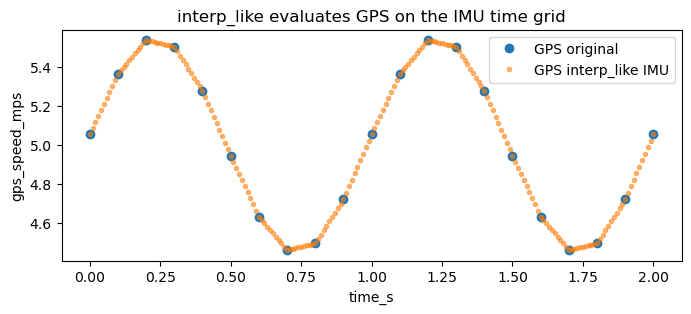

In [3]:
q = np.linspace(0.0, 2.0, 41)
imu_at = ao_imu.param.at(q, on='time_s', opts=ParamEvalOptions(method='linear'))
gps_rs = ao_gps.param.resample_to(q, on='time_s', opts=ParamEvalOptions(method='nearest'))
gps_on_imu = ao_gps.param.interp_like(ao_imu, on='time_s', opts=ParamEvalOptions(method='linear'))

display_result(
    'Param operation outputs',
    pd.DataFrame(
        [
            {'operation': 'imu.param.at(linear)', 'samples': imu_at.unsafe_data.sizes['sample'], 'vars': list(imu_at.unsafe_data.data_vars)},
            {'operation': 'gps.param.resample_to(nearest)', 'samples': gps_rs.unsafe_data.sizes['sample'], 'vars': list(gps_rs.unsafe_data.data_vars)},
            {'operation': 'gps.param.interp_like(imu)', 'samples': gps_on_imu.unsafe_data.sizes['sample'], 'vars': list(gps_on_imu.unsafe_data.data_vars)},
        ]
    ),
)

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(ao_gps.unsafe_data['time_s'], ao_gps.unsafe_data['gps_speed_mps'], 'o', label='GPS original')
ax.plot(gps_on_imu.unsafe_data['time_s'], gps_on_imu.unsafe_data['gps_speed_mps'], '.', alpha=0.55, label='GPS interp_like IMU')
ax.set(title='interp_like evaluates GPS on the IMU time grid', xlabel='time_s', ylabel='gps_speed_mps')
ax.legend(loc='best')


## Synchronize multiple objects

`synchronize(...)` chooses a common param grid and returns aligned AOs. The variables remain separate, but the sequence grid is now shared.


In [4]:
synced_imu, synced_gps = synchronize(
    [ao_imu, ao_gps],
    on='time_s',
    opts=ParamSyncOptions(join='domain', how='interp', batch_join='inner'),
    validate=True,
)

display_result(
    'Synchronized streams',
    pd.DataFrame(
        [
            {'stream': 'IMU', 'samples': synced_imu.unsafe_data.sizes['sample'], 'vars': list(synced_imu.unsafe_data.data_vars)},
            {'stream': 'GPS', 'samples': synced_gps.unsafe_data.sizes['sample'], 'vars': list(synced_gps.unsafe_data.data_vars)},
        ]
    ),
)


#### Synchronized streams

,stream,samples,vars
0,IMU,205,[imu_speed_mps]
1,GPS,205,[gps_speed_mps]


,stream,samples,vars
0,IMU,205,[imu_speed_mps]
1,GPS,205,[gps_speed_mps]


## Before vs after synchronize

The plot answers a specific question: did the two streams end up on the same time grid?


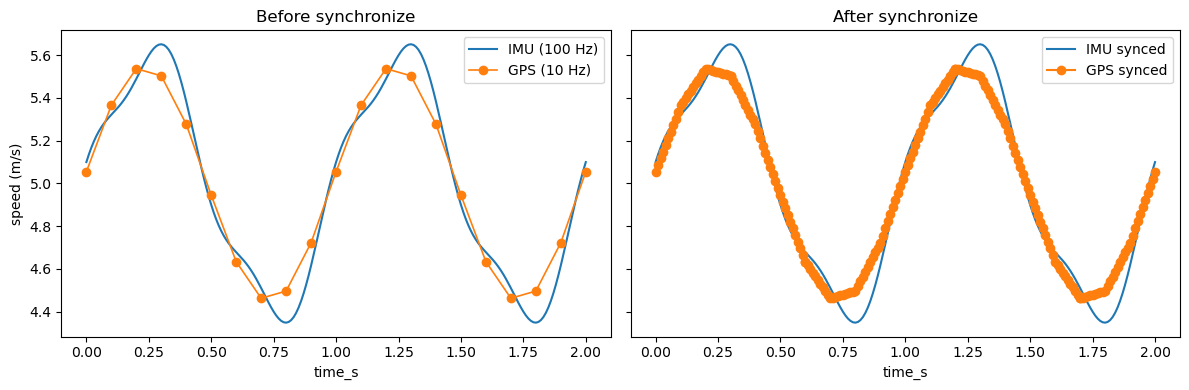

In [5]:
try:
    import matplotlib.pyplot as plt
except ImportError:
    plt = None
    print('Plot skipped: matplotlib is not installed.')

if plt is not None:
    imu_var = next(iter(ao_imu.unsafe_data.data_vars))
    gps_var = next(iter(ao_gps.unsafe_data.data_vars))
    synced_imu_var = next(iter(synced_imu.unsafe_data.data_vars))
    synced_gps_var = next(iter(synced_gps.unsafe_data.data_vars))

    fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

    axes[0].plot(ao_imu.unsafe_data['time_s'].values, ao_imu.unsafe_data[imu_var].values, label='IMU (100 Hz)', linewidth=1.5)
    axes[0].plot(ao_gps.unsafe_data['time_s'].values, ao_gps.unsafe_data[gps_var].values, 'o-', label='GPS (10 Hz)', linewidth=1.2)
    axes[0].set_title('Before synchronize')
    axes[0].set_xlabel('time_s')
    axes[0].set_ylabel('speed (m/s)')
    axes[0].legend(loc='best')

    axes[1].plot(synced_imu.unsafe_data['time_s'].values, synced_imu.unsafe_data[synced_imu_var].values, label='IMU synced', linewidth=1.5)
    axes[1].plot(synced_gps.unsafe_data['time_s'].values, synced_gps.unsafe_data[synced_gps_var].values, 'o-', label='GPS synced', linewidth=1.5)
    axes[1].set_title('After synchronize')
    axes[1].set_xlabel('time_s')
    axes[1].legend(loc='best')

    plt.tight_layout()
    plt.show()


What to notice

The GPS stream keeps its semantic role as a scalar trajectory, but its samples are evaluated on the synchronized grid.


## Duplicate timestamp policy

Duplicate param values are ambiguous for interpolation. The policy option makes that ambiguity explicit.


In [6]:
print(f"GPS samples before sync: {ao_gps.unsafe_data.sizes['sample']}")
print(f"GPS samples after sync:  {synced_gps.unsafe_data.sizes['sample']}")


GPS samples before sync: 21
GPS samples after sync:  205


In [7]:
dup_ds = xr.Dataset(
    data_vars={'x': ('sample', np.array([0.0, 1.0, 2.0], dtype=float))},
    coords={
        'sample': np.arange(3),
        'time_s': ('sample', np.array([0.0, 0.0, 1.0], dtype=float)),
    },
)
dup_ao = AnalysisObject.from_data(dup_ds, sequence_dim='sample', core_dims=(), param_coord='time_s', validate=True)
try:
    dup_ao.param.at([0.2], on='time_s', opts=ParamEvalOptions(method='linear', duplicate_policy='raise'))
except ValueError as exc:
    print('duplicate policy fail-closed:', str(exc).split(':')[0])


## Takeaways

- `.param.at` evaluates one object on requested coordinates.
- `.param.interp_like` uses another object as the query grid.
- `synchronize` aligns multiple objects under explicit join/policy choices.

**Exercise:** change `ParamSyncOptions(join=...)` and compare output sample counts.
